In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv('train.csv')
train_label = pd.read_csv('train_label.csv', header=None)
test = pd.read_csv('test.csv')
test_label = pd.read_csv('test_label.csv', header=None)
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,5/2/2012 19:00,Summer,0,1,Clear + Few clouds,22.14,25.760,77,16.9979
1,9/5/2012 4:00,Fall,0,1,Clear + Few clouds,28.70,33.335,79,19.0012
2,1/13/2011 9:00,Spring,0,1,Clear + Few clouds,5.74,6.060,50,22.0028
3,11/18/2011 16:00,Winter,0,1,Clear + Few clouds,13.94,16.665,29,8.9981
4,9/13/2011 13:00,Fall,0,1,Clear + Few clouds,30.34,33.335,51,19.0012


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8708 entries, 0 to 8707
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    8708 non-null   str    
 1   season      8708 non-null   str    
 2   holiday     8708 non-null   int64  
 3   workingday  8708 non-null   int64  
 4   weather     8708 non-null   str    
 5   temp        8708 non-null   float64
 6   atemp       8708 non-null   float64
 7   humidity    8708 non-null   int64  
 8   windspeed   8708 non-null   float64
dtypes: float64(3), int64(3), str(3)
memory usage: 936.7 KB


In [4]:
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2012-05-02 19:00:00,Summer,0,1,Clear + Few clouds,22.14,25.760,77,16.9979
1,2012-09-05 04:00:00,Fall,0,1,Clear + Few clouds,28.70,33.335,79,19.0012
2,2011-01-13 09:00:00,Spring,0,1,Clear + Few clouds,5.74,6.060,50,22.0028
3,2011-11-18 16:00:00,Winter,0,1,Clear + Few clouds,13.94,16.665,29,8.9981
4,2011-09-13 13:00:00,Fall,0,1,Clear + Few clouds,30.34,33.335,51,19.0012


In [5]:
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour

In [6]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour
0,2012-05-02 19:00:00,Summer,0,1,Clear + Few clouds,22.14,25.760,77,16.9979,2012,5,2,19
1,2012-09-05 04:00:00,Fall,0,1,Clear + Few clouds,28.70,33.335,79,19.0012,2012,9,5,4
2,2011-01-13 09:00:00,Spring,0,1,Clear + Few clouds,5.74,6.060,50,22.0028,2011,1,13,9
3,2011-11-18 16:00:00,Winter,0,1,Clear + Few clouds,13.94,16.665,29,8.9981,2011,11,18,16
4,2011-09-13 13:00:00,Fall,0,1,Clear + Few clouds,30.34,33.335,51,19.0012,2011,9,13,13


In [7]:
test['year'] = test['datetime'].dt.year
test['month'] = test['datetime'].dt.month
test['day'] = test['datetime'].dt.day
test['hour'] = test['datetime'].dt.hour
test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour
0,2012-05-10 11:00:00,Summer,0,1,Clear + Few clouds,21.32,25.000,48,35.0008,2012,5,10,11
1,2012-06-09 07:00:00,Summer,0,0,Clear + Few clouds,23.78,27.275,64,7.0015,2012,6,9,7
2,2011-03-06 20:00:00,Spring,0,0,"Light Snow, Light Rain",11.48,12.120,100,27.9993,2011,3,6,20
3,2011-10-13 11:00:00,Winter,0,1,Mist + Cloudy,25.42,28.790,83,0.0000,2011,10,13,11
4,2012-06-02 12:00:00,Summer,0,0,Clear + Few clouds,25.42,31.060,43,23.9994,2012,6,2,12


In [8]:
train['Bookings'] = train_label
test['Bookings'] = test_label
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,Bookings
0,2012-05-02 19:00:00,Summer,0,1,Clear + Few clouds,22.14,25.760,77,16.9979,2012,5,2,19,504
1,2012-09-05 04:00:00,Fall,0,1,Clear + Few clouds,28.70,33.335,79,19.0012,2012,9,5,4,5
2,2011-01-13 09:00:00,Spring,0,1,Clear + Few clouds,5.74,6.060,50,22.0028,2011,1,13,9,139
3,2011-11-18 16:00:00,Winter,0,1,Clear + Few clouds,13.94,16.665,29,8.9981,2011,11,18,16,209
4,2011-09-13 13:00:00,Fall,0,1,Clear + Few clouds,30.34,33.335,51,19.0012,2011,9,13,13,184


In [9]:
train['season'].unique()

<ArrowStringArray>
['Summer', 'Fall', 'Spring', 'Winter']
Length: 4, dtype: str

In [10]:
train['season'].value_counts()

season
Summer    2197
Fall      2189
Winter    2186
Spring    2136
Name: count, dtype: int64

In [11]:
train['weather'].unique()

<ArrowStringArray>
[        ' Clear + Few clouds',     ' Light Snow, Light Rain',
             ' Mist + Cloudy ', ' Heavy Rain + Thunderstorm ']
Length: 4, dtype: str

In [12]:
train['weather'].value_counts()

weather
Clear + Few clouds            5753
Mist + Cloudy                 2276
Light Snow, Light Rain         678
Heavy Rain + Thunderstorm        1
Name: count, dtype: int64

In [13]:
lab_enc = LabelEncoder()
train['season'] = lab_enc.fit_transform(train['season'])
train['weather'] = lab_enc.fit_transform(train['weather'])

test['season'] = lab_enc.fit_transform(test['season'])
test['weather'] = lab_enc.fit_transform(test['weather'])

In [14]:
train = train.drop(columns=['datetime'])
train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,Bookings
0,2,0,1,0,22.14,25.760,77,16.9979,2012,5,2,19,504
1,0,0,1,0,28.70,33.335,79,19.0012,2012,9,5,4,5
2,1,0,1,0,5.74,6.060,50,22.0028,2011,1,13,9,139
3,3,0,1,0,13.94,16.665,29,8.9981,2011,11,18,16,209
4,0,0,1,0,30.34,33.335,51,19.0012,2011,9,13,13,184


In [15]:
test = test.drop(columns=['datetime'])
test.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,Bookings
0,2,0,1,0,21.32,25.000,48,35.0008,2012,5,10,11,256
1,2,0,0,0,23.78,27.275,64,7.0015,2012,6,9,7,87
2,1,0,0,1,11.48,12.120,100,27.9993,2011,3,6,20,11
3,3,0,1,2,25.42,28.790,83,0.0000,2011,10,13,11,84
4,2,0,0,0,25.42,31.060,43,23.9994,2012,6,2,12,668


In [16]:
train.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'Bookings'],
      dtype='str')

In [17]:
test.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'Bookings'],
      dtype='str')

In [18]:
print(f'we have {train.shape[0]} rows and {train.shape[1]} columns in train data')
print(f'we have {test.shape[0]} rows and {test.shape[1]} columns in test data')

we have 8708 rows and 13 columns in train data
we have 2178 rows and 13 columns in test data


In [19]:
train['Bookings'].describe()

count    8708.000000
mean      193.007005
std       181.552211
min         1.000000
25%        43.000000
50%       148.000000
75%       286.000000
max       977.000000
Name: Bookings, dtype: float64

In [20]:
test['Bookings'].describe()

count    2178.000000
mean      185.845271
std       179.431987
min         1.000000
25%        38.000000
50%       136.000000
75%       277.000000
max       901.000000
Name: Bookings, dtype: float64

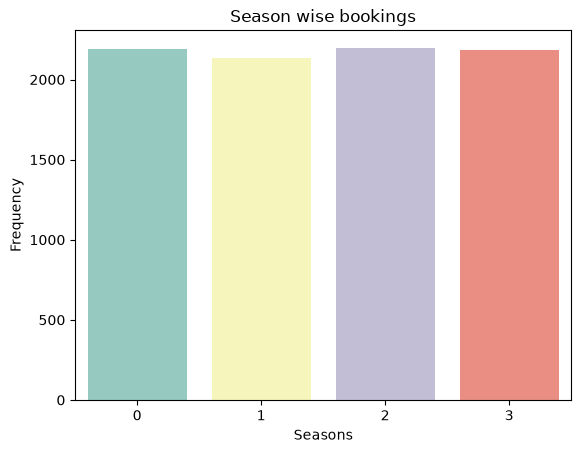

In [21]:
sns.countplot(x='season', data=train, hue='season', palette='Set3', legend=False)
plt.xlabel('Seasons')
plt.ylabel('Frequency')
plt.title('Season wise bookings')
plt.show()

In [22]:
train['weather'].unique()

array([0, 2, 3, 1])

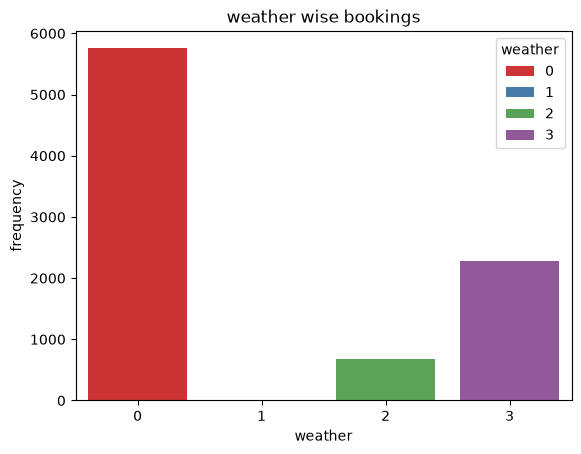

In [23]:
sns.countplot(x='weather', data=train, hue='weather', palette='Set1')
plt.xlabel('weather')
plt.ylabel('frequency')
plt.title('weather wise bookings')
plt.show()

Text(0.5, 1.0, 'Distribution of Bookings')

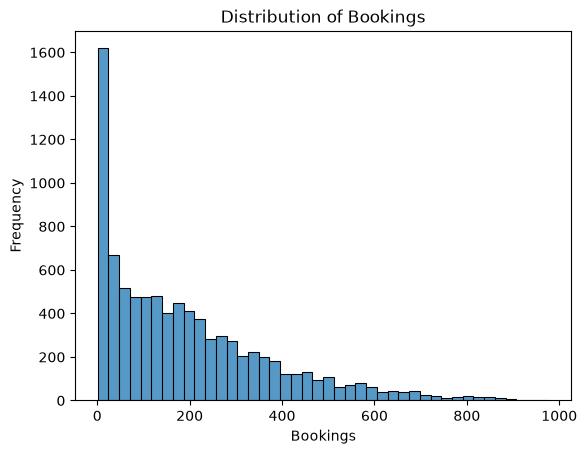

In [24]:
sns.histplot(train['Bookings'], kde=False)
plt.xlabel('Bookings')
plt.ylabel('Frequency')
plt.title('Distribution of Bookings')

Text(0.5, 1.0, 'weather wise bookings')

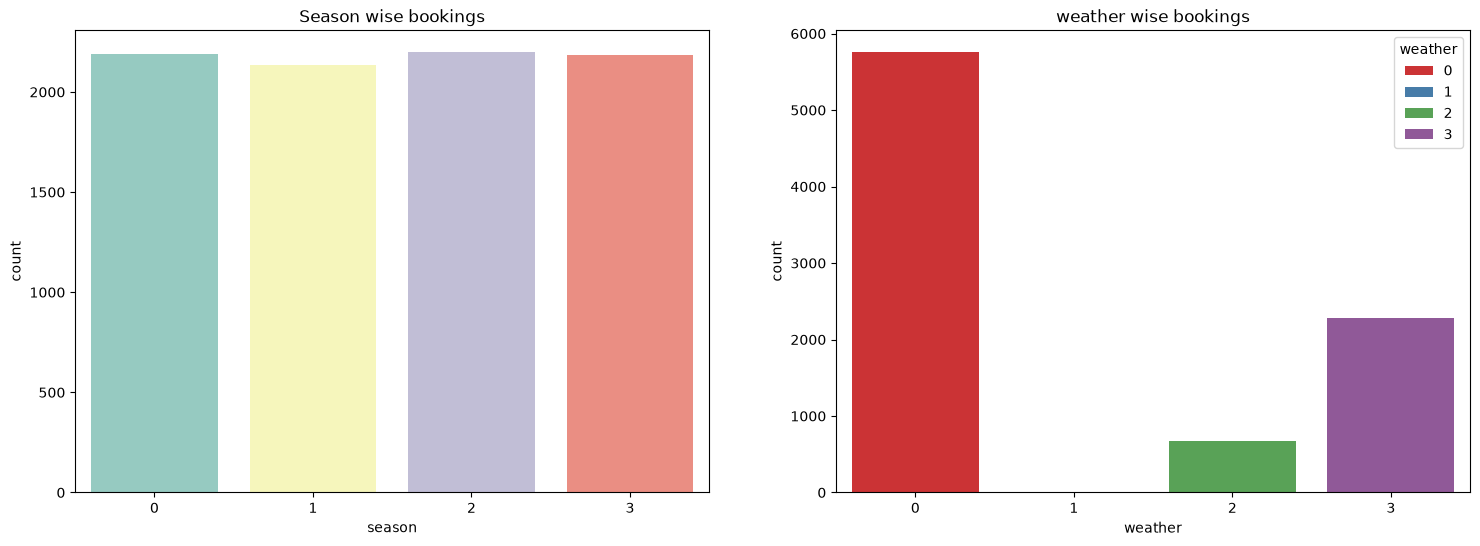

In [25]:
fig, axes= plt.subplots(nrows=1, ncols=2, figsize=(18,6))

sns.countplot(x='season', data=train, hue='season', palette='Set3', ax=axes[0], legend=False)
axes[0].set_title('Season wise bookings')

sns.countplot(x='weather', data=train, hue='weather', palette='Set1', ax=axes[1])
axes[1].set_title('weather wise bookings')

Text(0.5, 1.0, 'hour wise bookings')

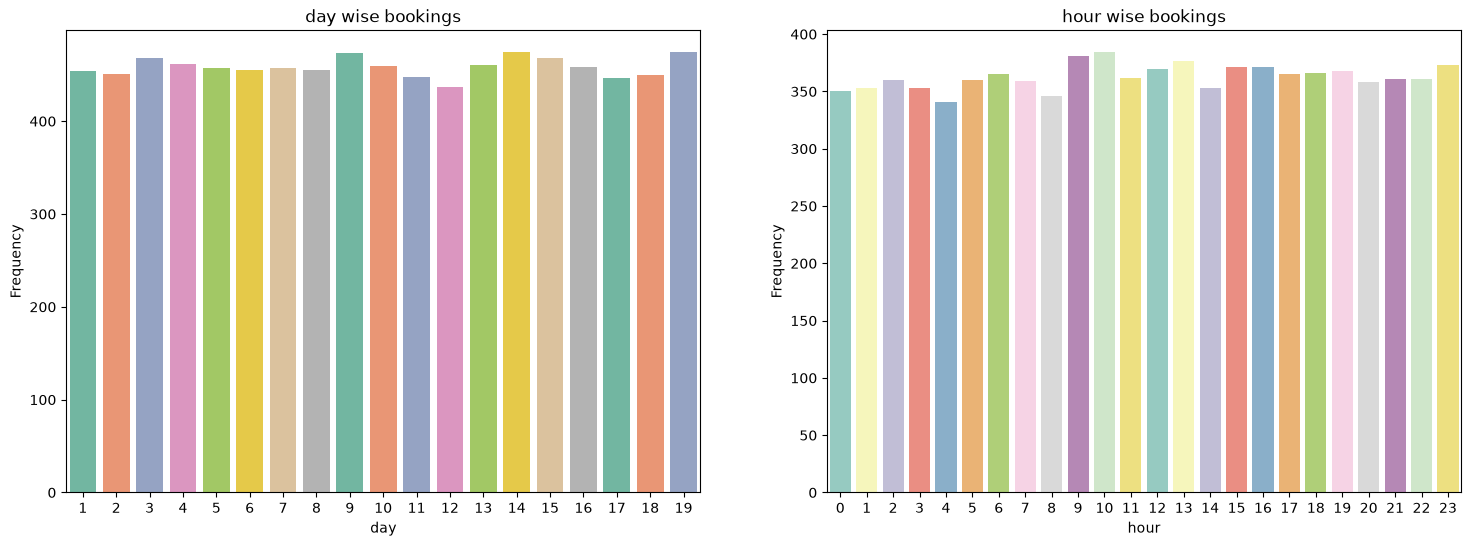

In [26]:
fig, axes=plt.subplots(nrows=1, ncols=2, figsize=(18,6))

sns.countplot(x='day', data=train, hue='day', palette='Set2', ax=axes[0], legend=False)
axes[0].set_xlabel('day')
axes[0].set_ylabel('Frequency')
axes[0].set_title('day wise bookings')

sns.countplot(x='hour', data=train, hue='hour', palette='Set3', ax=axes[1], legend=False)
axes[1].set_xlabel('hour')
axes[1].set_ylabel('Frequency')
axes[1].set_title('hour wise bookings')

Text(0.5, 1.0, 'month wise bookings')

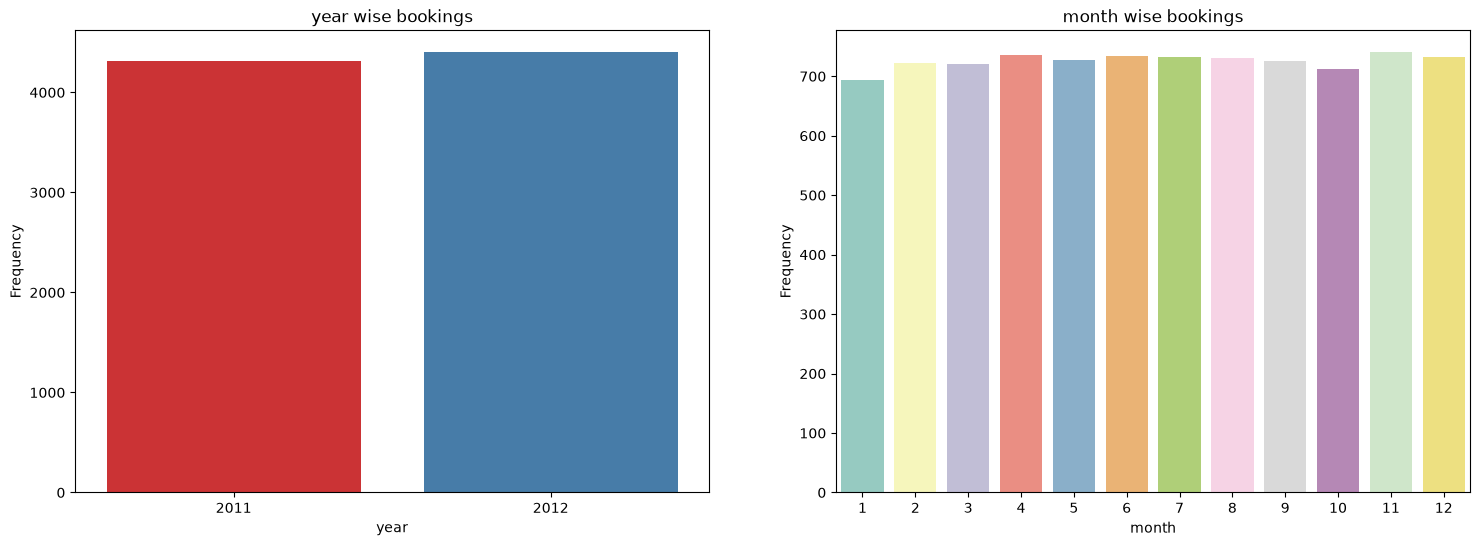

In [27]:
fig, axes= plt.subplots(nrows=1, ncols=2, figsize=(18,6))

sns.countplot(x='year', data=train, hue='year', palette='Set1', ax=axes[0], legend=False)
axes[0].set_xlabel('year')
axes[0].set_ylabel('Frequency')
axes[0].set_title('year wise bookings')

sns.countplot(x='month', data=train, hue='month', palette='Set3', ax=axes[1], legend=False)
axes[1].set_xlabel('month')
axes[1].set_ylabel('Frequency')
axes[1].set_title('month wise bookings')

Text(0.5, 1.0, 'year wise bookings')

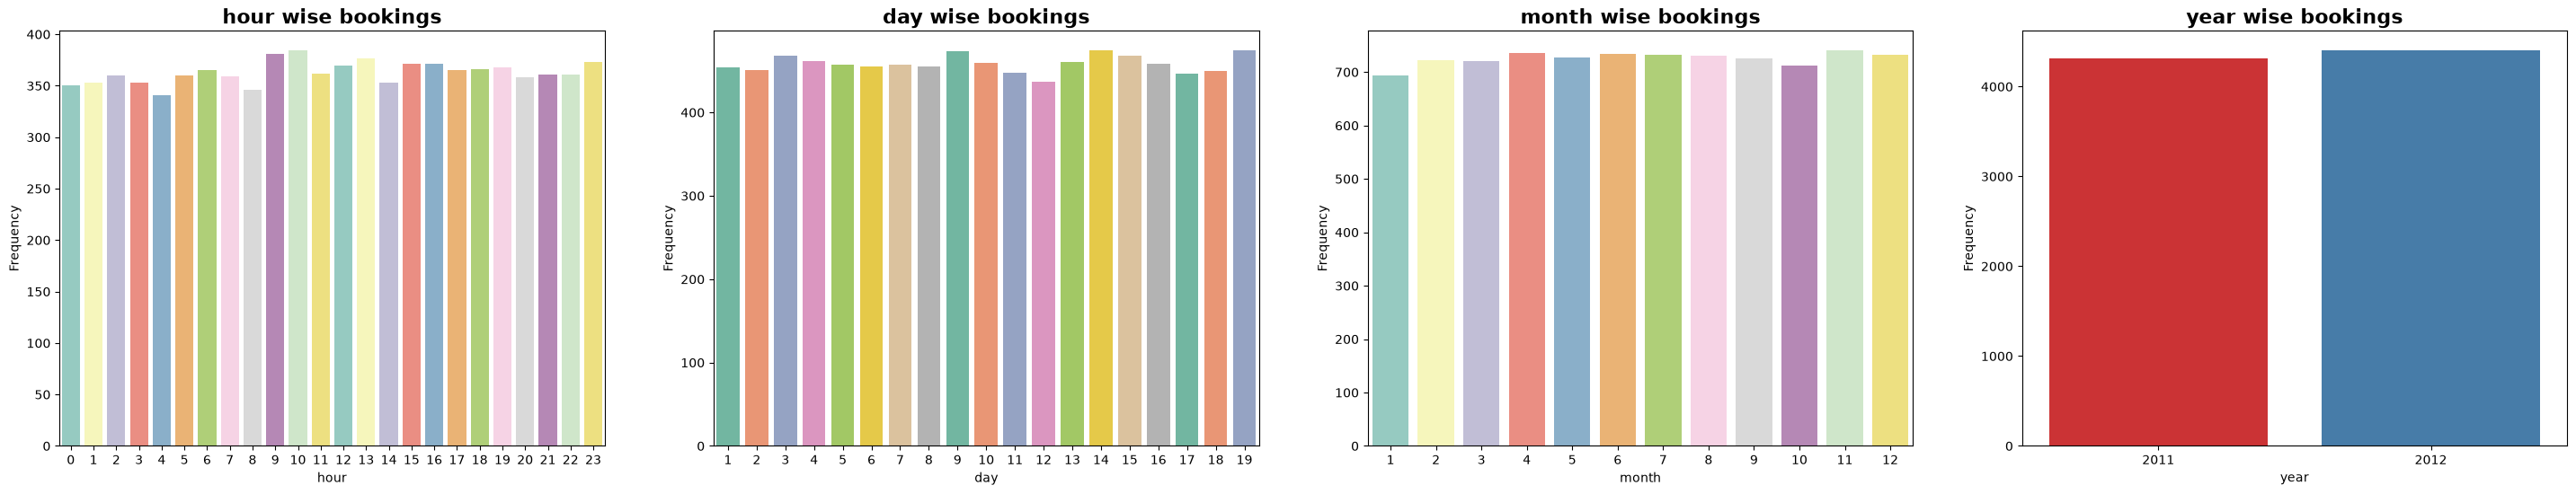

In [28]:
fig, axes=plt.subplots(nrows=1, ncols=4, figsize=(36,6))

sns.countplot(x='hour', data=train, hue='hour', palette='Set3', ax=axes[0], legend=False)
axes[0].set_xlabel('hour')
axes[0].set_ylabel('Frequency')
axes[0].set_title('hour wise bookings', size=16, fontweight='bold')

sns.countplot(x='day', data=train, hue='day', palette='Set2', ax=axes[1], legend=False)
axes[1].set_xlabel('day')
axes[1].set_ylabel('Frequency')
axes[1].set_title('day wise bookings', size=16, fontweight='bold')

sns.countplot(x='month', data=train, hue='month', palette='Set3', ax=axes[2], legend=False)
axes[2].set_xlabel('month')
axes[2].set_ylabel('Frequency')
axes[2].set_title('month wise bookings', size=16, fontweight='bold')

sns.countplot(x='year', data=train, hue='year', palette='Set1', ax=axes[3], legend=False)
axes[3].set_xlabel('year')
axes[3].set_ylabel('Frequency')
axes[3].set_title('year wise bookings', size=16, fontweight='bold')

In [29]:
train.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'Bookings'],
      dtype='str')

<Axes: xlabel='workingday', ylabel='Bookings'>

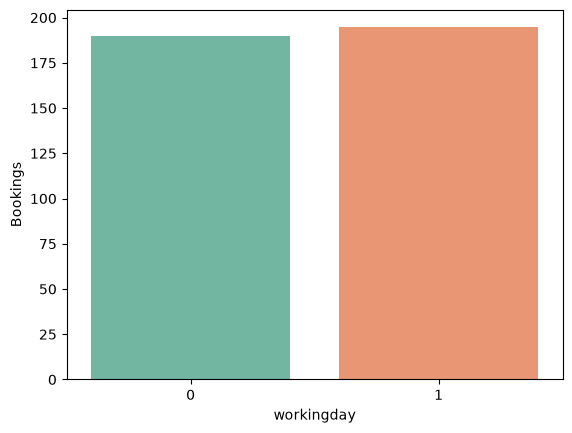

In [30]:
avg_weekday_booking = (train.groupby(['workingday'])['Bookings'].mean()).reset_index()
sns.barplot(data=avg_weekday_booking, x='workingday', y='Bookings', hue='workingday', palette='Set2', legend=False)

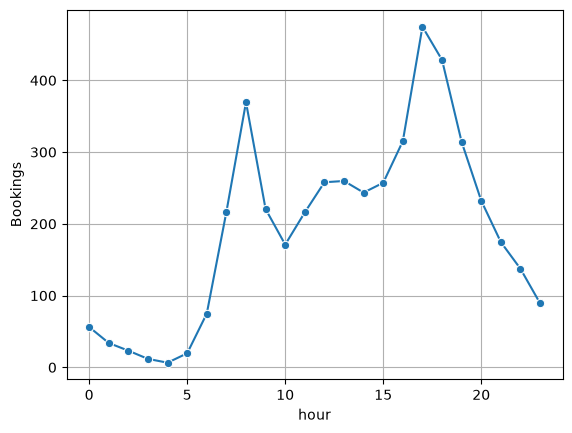

In [31]:
avg_hour_booking = (train.groupby(['hour'])['Bookings'].mean()).reset_index()
sns.lineplot(data=avg_hour_booking, x='hour', y='Bookings', legend=False, marker='o')
plt.grid(True)

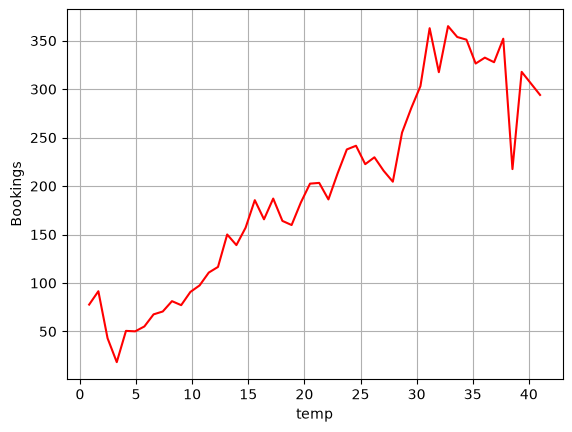

In [32]:
avg_temp_booking = (train.groupby(['temp'])['Bookings'].mean()).reset_index()
sns.lineplot(data=avg_temp_booking, x='temp', y='Bookings', legend=False, c='r')
plt.grid(True)

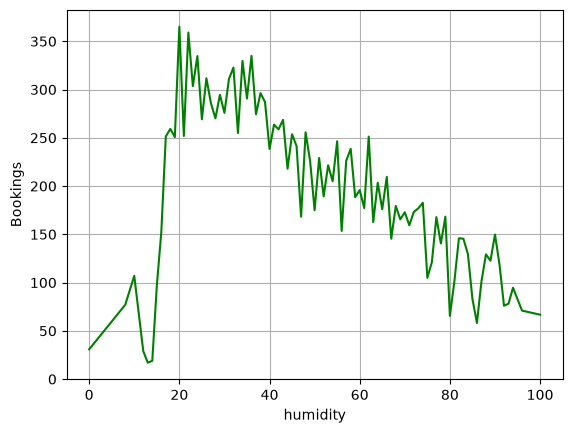

In [33]:
avg_humidity_booking = (train.groupby(['humidity'])['Bookings'].mean()).reset_index()
sns.lineplot(data=avg_humidity_booking, x='humidity', y='Bookings', legend=False, c='g')
plt.grid(True)

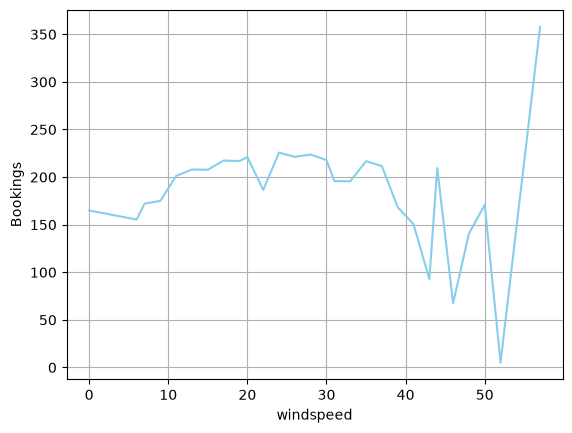

In [34]:
avg_windspeed_bookings = (train.groupby(['windspeed'])['Bookings'].mean()).reset_index()
sns.lineplot(data=avg_windspeed_bookings, x='windspeed', y='Bookings', legend=False, c='skyblue')
plt.grid(True)

<Axes: xlabel='Bookings'>

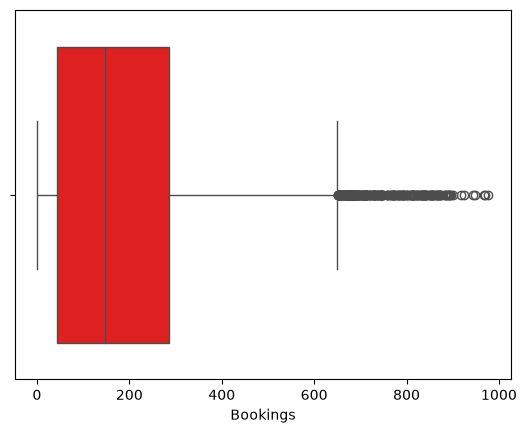

In [35]:
sns.boxplot(x=train['Bookings'], color='r')

In [36]:
train['Bookings'] = train['Bookings'].clip(upper=650)
train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,Bookings
0,2,0,1,0,22.14,25.760,77,16.9979,2012,5,2,19,504
1,0,0,1,0,28.70,33.335,79,19.0012,2012,9,5,4,5
2,1,0,1,0,5.74,6.060,50,22.0028,2011,1,13,9,139
3,3,0,1,0,13.94,16.665,29,8.9981,2011,11,18,16,209
4,0,0,1,0,30.34,33.335,51,19.0012,2011,9,13,13,184


<Axes: xlabel='Bookings'>

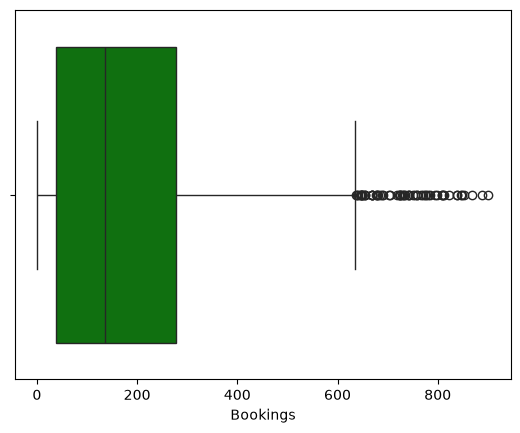

In [37]:
sns.boxplot(x=test['Bookings'], color='g')

In [38]:
test['Bookings'] = test['Bookings'].clip(upper=650)
test.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,Bookings
0,2,0,1,0,21.32,25.000,48,35.0008,2012,5,10,11,256
1,2,0,0,0,23.78,27.275,64,7.0015,2012,6,9,7,87
2,1,0,0,1,11.48,12.120,100,27.9993,2011,3,6,20,11
3,3,0,1,2,25.42,28.790,83,0.0000,2011,10,13,11,84
4,2,0,0,0,25.42,31.060,43,23.9994,2012,6,2,12,650


In [39]:
train = train[~((train['holiday'] == 1) & (train['workingday'] == 1 ))]
test = test[~((test['holiday'] == 1) & (test['workingday'] == 1 ))]

<Axes: xlabel='log_total_Bookings', ylabel='Count'>

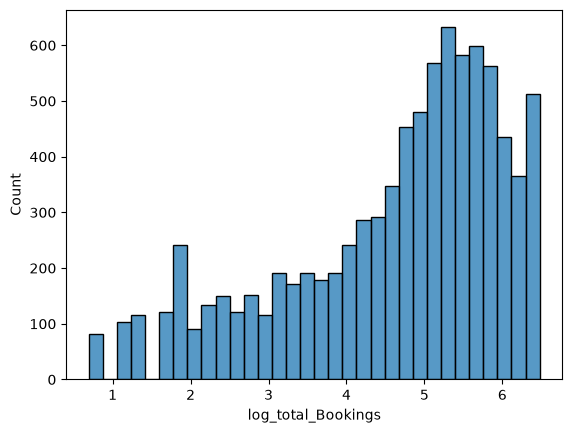

In [40]:
train['log_total_Bookings'] = np.log1p(train['Bookings'])
sns.histplot(train['log_total_Bookings'], kde=False)

In [41]:
train = train.drop(columns=['log_total_Bookings'])

In [42]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()
df = st.fit_transform(train)
train = pd.DataFrame(df, columns=train.columns)
df1 = st.transform(test)
test = pd.DataFrame(df1, columns=test.columns)

<Axes: >

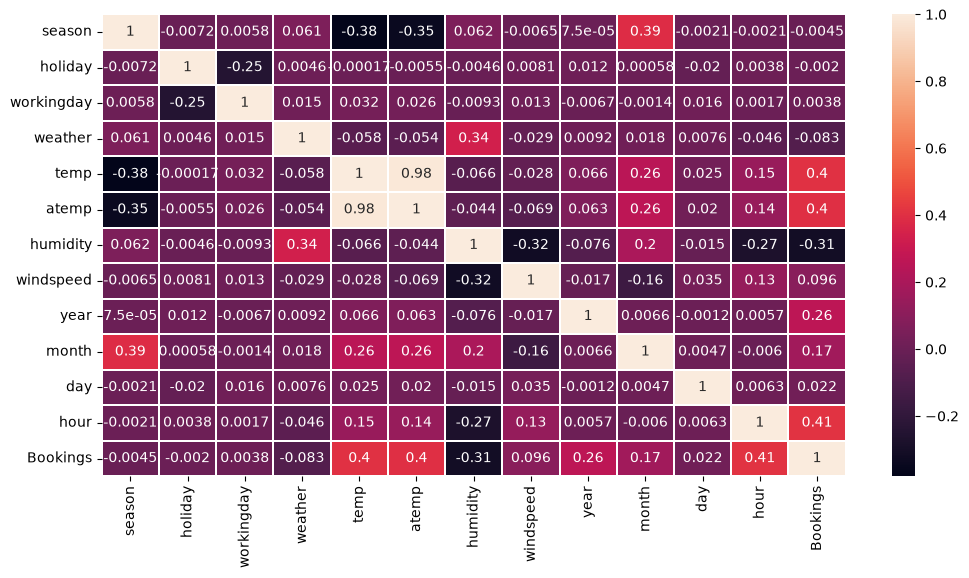

In [43]:
plt.figure(figsize=(12,6))
corr = train.corr()
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2)

In [44]:
train = train.drop(columns=['atemp'])
test = test.drop(columns=['atemp'])
train.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,year,month,day,hour,Bookings
0,0.443689,-0.171215,0.685531,-0.704439,0.242796,0.799586,0.507215,0.989718,-0.444304,-1.461533,1.076729,1.816491
1,-1.341730,-0.171215,0.685531,-0.704439,1.082418,0.903761,0.751823,0.989718,0.718256,-0.914111,-1.100296,-1.071482
2,-0.449020,-0.171215,0.685531,-0.704439,-1.856257,-0.606776,1.118325,-1.010389,-1.606865,0.545684,-0.374621,-0.295954
3,1.336399,-0.171215,0.685531,-0.704439,-0.806730,-1.700613,-0.469580,-1.010389,1.299536,1.458055,0.641324,0.109172
4,-1.341730,-0.171215,0.685531,-0.704439,1.292323,-0.554688,0.751823,-1.010389,0.718256,0.545684,0.205919,-0.035516


In [45]:
train.dtypes

season        float64
holiday       float64
workingday    float64
weather       float64
temp          float64
humidity      float64
windspeed     float64
year          float64
month         float64
day           float64
hour          float64
Bookings      float64
dtype: object

In [46]:
test.dtypes

season        float64
holiday       float64
workingday    float64
weather       float64
temp          float64
humidity      float64
windspeed     float64
year          float64
month         float64
day           float64
hour          float64
Bookings      float64
dtype: object

In [47]:
train.isna().sum()

season        0
holiday       0
workingday    0
weather       0
temp          0
humidity      0
windspeed     0
year          0
month         0
day           0
hour          0
Bookings      0
dtype: int64

In [48]:
test.isna().sum()

season        0
holiday       0
workingday    0
weather       0
temp          0
humidity      0
windspeed     0
year          0
month         0
day           0
hour          0
Bookings      0
dtype: int64

<Axes: xlabel='Bookings'>

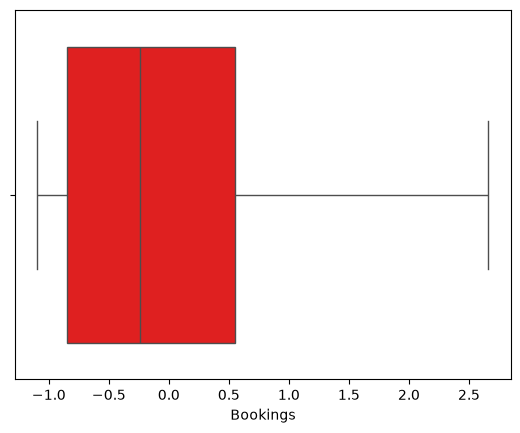

In [49]:
sns.boxplot(x='Bookings', data=train, color='r')

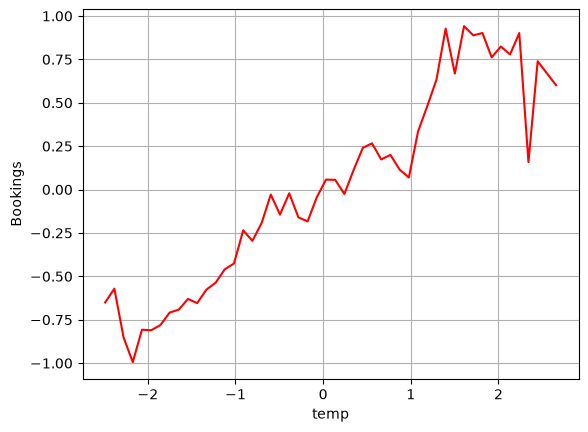

In [50]:
avg_temp_bookings = (train.groupby('temp')['Bookings'].mean()).reset_index()
sns.lineplot(x='temp', y='Bookings', data=avg_temp_bookings, color='r')
plt.grid()

In [51]:
# model building
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt

In [52]:
train.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,year,month,day,hour,Bookings
0,0.443689,-0.171215,0.685531,-0.704439,0.242796,0.799586,0.507215,0.989718,-0.444304,-1.461533,1.076729,1.816491
1,-1.341730,-0.171215,0.685531,-0.704439,1.082418,0.903761,0.751823,0.989718,0.718256,-0.914111,-1.100296,-1.071482
2,-0.449020,-0.171215,0.685531,-0.704439,-1.856257,-0.606776,1.118325,-1.010389,-1.606865,0.545684,-0.374621,-0.295954
3,1.336399,-0.171215,0.685531,-0.704439,-0.806730,-1.700613,-0.469580,-1.010389,1.299536,1.458055,0.641324,0.109172
4,-1.341730,-0.171215,0.685531,-0.704439,1.292323,-0.554688,0.751823,-1.010389,0.718256,0.545684,0.205919,-0.035516


In [53]:
xtrain = train.iloc[:,:-1]
ytrain = train.iloc[:,-1]

In [54]:
test.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,year,month,day,hour,Bookings
0,0.443689,-0.171215,0.685531,-0.704439,0.137844,-0.710951,2.705413,0.989718,-0.444304,-0.001739,-0.084351,0.381185
1,0.443689,-0.171215,-1.458723,-0.704439,0.452702,0.122449,-0.713370,0.989718,-0.153664,-0.184214,-0.664891,-0.596906
2,-0.449020,-0.171215,-1.458723,0.045012,-1.121588,1.997598,1.850513,-1.010389,-1.025584,-0.731636,1.221864,-1.036757
3,1.336399,-0.171215,0.685531,0.794463,0.662607,1.112111,-1.568271,-1.010389,1.008896,0.545684,-0.084351,-0.614268
4,0.443689,-0.171215,-1.458723,-0.704439,0.662607,-0.971388,1.362115,0.989718,-0.153664,-1.461533,0.060784,2.661469


In [55]:
xtest = test.iloc[:,:-1]
ytest = test.iloc[:,-1]

In [56]:
def cross_validation_score(ml_model, cols=xtrain.columns):
    cv_scores=[]

    kf = KFold(n_splits=5, random_state=24, shuffle=True)
    for i, (train_index, test_index) in enumerate(kf.split(xtrain, ytrain), 1):
        x_tr, x_te = xtrain.iloc[train_index], xtrain.iloc[test_index]
        y_tr, y_te = ytrain.iloc[train_index], ytrain.iloc[test_index]

        model = ml_model
        model.fit(x_tr, y_tr)
        pred_val = model.predict(x_te)

        rmse_score = sqrt(mean_squared_error(y_te, pred_val))
        print(f'{i} of kfold {kf.n_splits} - RMSE score: {rmse_score}')

        cv_scores.append(rmse_score)

    return cv_scores      

In [57]:
linreg_score = cross_validation_score(LinearRegression())

1 of kfold 5 - RMSE score: 0.7706066644090506
2 of kfold 5 - RMSE score: 0.7935241918405748
3 of kfold 5 - RMSE score: 0.7678252221255164
4 of kfold 5 - RMSE score: 0.7761739967172665
5 of kfold 5 - RMSE score: 0.7569571172894405


In [58]:
dtree_scores = cross_validation_score(DecisionTreeRegressor(min_samples_leaf=5, min_samples_split=20))

1 of kfold 5 - RMSE score: 0.3169096916156188
2 of kfold 5 - RMSE score: 0.32520513926170475
3 of kfold 5 - RMSE score: 0.2931408010378548
4 of kfold 5 - RMSE score: 0.31314782330210184
5 of kfold 5 - RMSE score: 0.33463524306742026


In [59]:
knn_scores = cross_validation_score(KNeighborsRegressor(n_neighbors=2))

1 of kfold 5 - RMSE score: 0.6487264000200792
2 of kfold 5 - RMSE score: 0.6519304319929302
3 of kfold 5 - RMSE score: 0.6527555430656785
4 of kfold 5 - RMSE score: 0.6703269973140554
5 of kfold 5 - RMSE score: 0.6131332294227674


In [60]:
ridge_scores = cross_validation_score(Ridge(alpha=1.0))

1 of kfold 5 - RMSE score: 0.7706070550973279
2 of kfold 5 - RMSE score: 0.7935246352521639
3 of kfold 5 - RMSE score: 0.7678212374136335
4 of kfold 5 - RMSE score: 0.7761746434284568
5 of kfold 5 - RMSE score: 0.7569586968741234


In [61]:
lasso_scores = cross_validation_score(Lasso(alpha=0.1))

1 of kfold 5 - RMSE score: 0.801017961387098
2 of kfold 5 - RMSE score: 0.8213134724717447
3 of kfold 5 - RMSE score: 0.7875967246176522
4 of kfold 5 - RMSE score: 0.8079776448667194
5 of kfold 5 - RMSE score: 0.797815816237744


In [62]:
linreg_dtree = pd.DataFrame({'linear regression': linreg_score, 'Dtree': dtree_scores, 'knn': knn_scores, 'Ridge': ridge_scores, 'Lasso': lasso_scores})
linreg_dtree.head()

,linear regression,Dtree,knn,Ridge,Lasso
0,0.770607,0.316910,0.648726,0.770607,0.801018
1,0.793524,0.325205,0.651930,0.793525,0.821313
2,0.767825,0.293141,0.652756,0.767821,0.787597
3,0.776174,0.313148,0.670327,0.776175,0.807978
4,0.756957,0.334635,0.613133,0.756959,0.797816


Text(0.5, 1.0, 'RMSE score')

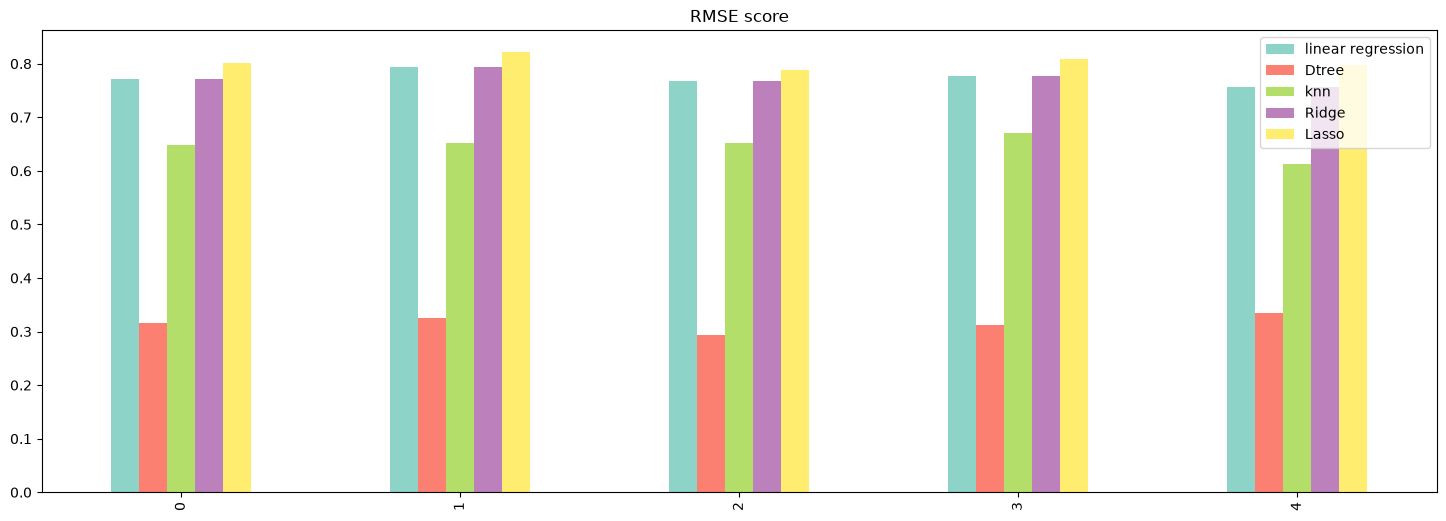

In [63]:
y = ['linear regression', 'Dtree','knn','Ridge','Lasso']
linreg_dtree.plot.bar(y=y, figsize=(18,6), colormap='Set3')
plt.title('RMSE score')

In [64]:
param_grids = {'max_depth' : [3, 5, 10, 15, 20],'min_samples_leaf' : [1, 2, 5, 10],'min_samples_split' : [2, 5, 10, 20]}
dtree = DecisionTreeRegressor(random_state=42)
grid = GridSearchCV(param_grid=param_grids, estimator=dtree, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(xtrain, ytrain)
print('Best params:', grid.best_params_)
print('Best RMSE:', np.sqrt(-grid.best_score_))

Best params: {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best RMSE: 0.3231582886369104


In [65]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

In [66]:
rf_params = {'random_state':26, 'max_depth':20, 'min_samples_leaf':5, 'min_samples_split':20, 'n_estimators':25, 'n_jobs':-1}
rf_scores = cross_validation_score(RandomForestRegressor(**rf_params))

1 of kfold 5 - RMSE score: 0.28325675026588487
2 of kfold 5 - RMSE score: 0.29313912042347
3 of kfold 5 - RMSE score: 0.2727091128155527
4 of kfold 5 - RMSE score: 0.2839987310864735
5 of kfold 5 - RMSE score: 0.2894732712440051


In [67]:
gb_params = {'max_depth':20, 'min_samples_split':2, 'n_estimators':25, 'learning_rate':0.1, 'loss':'squared_error'}
gb_scores = cross_validation_score(GradientBoostingRegressor(**gb_params))

1 of kfold 5 - RMSE score: 0.3373652997118938
2 of kfold 5 - RMSE score: 0.32919361342116
3 of kfold 5 - RMSE score: 0.3216117286447995
4 of kfold 5 - RMSE score: 0.32372204439529845
5 of kfold 5 - RMSE score: 0.3708002128532289


In [68]:
ada_scores = cross_validation_score(AdaBoostRegressor(n_estimators=50, random_state=0))

1 of kfold 5 - RMSE score: 0.5946492681185531
2 of kfold 5 - RMSE score: 0.6104018580627837
3 of kfold 5 - RMSE score: 0.5911905856469759
4 of kfold 5 - RMSE score: 0.6046834709868134
5 of kfold 5 - RMSE score: 0.5843919902463139


In [69]:
xgb_scores= cross_validation_score(XGBRegressor(max_depth=8,learning_rate=0.1,n_estimators=50, min_child_weight=5,
                                                random_state=42,objective='reg:squarederror',reg_lambda=5))

1 of kfold 5 - RMSE score: 0.24060589906772087
2 of kfold 5 - RMSE score: 0.24435395834070867
3 of kfold 5 - RMSE score: 0.22277565253293186
4 of kfold 5 - RMSE score: 0.23776582315945288
5 of kfold 5 - RMSE score: 0.24310288846337064


In [70]:
rf_xgb = pd.DataFrame({'Random forest': rf_scores, 'GradientboostingRegressor': gb_scores, 'AdaBoostRegressor': ada_scores, 'XGBRegressor': xgb_scores})
rf_xgb.head()

,Random forest,GradientboostingRegressor,AdaBoostRegressor,XGBRegressor
0,0.283257,0.337365,0.594649,0.240606
1,0.293139,0.329194,0.610402,0.244354
2,0.272709,0.321612,0.591191,0.222776
3,0.283999,0.323722,0.604683,0.237766
4,0.289473,0.370800,0.584392,0.243103


Text(0.5, 1.0, 'Rmse score')

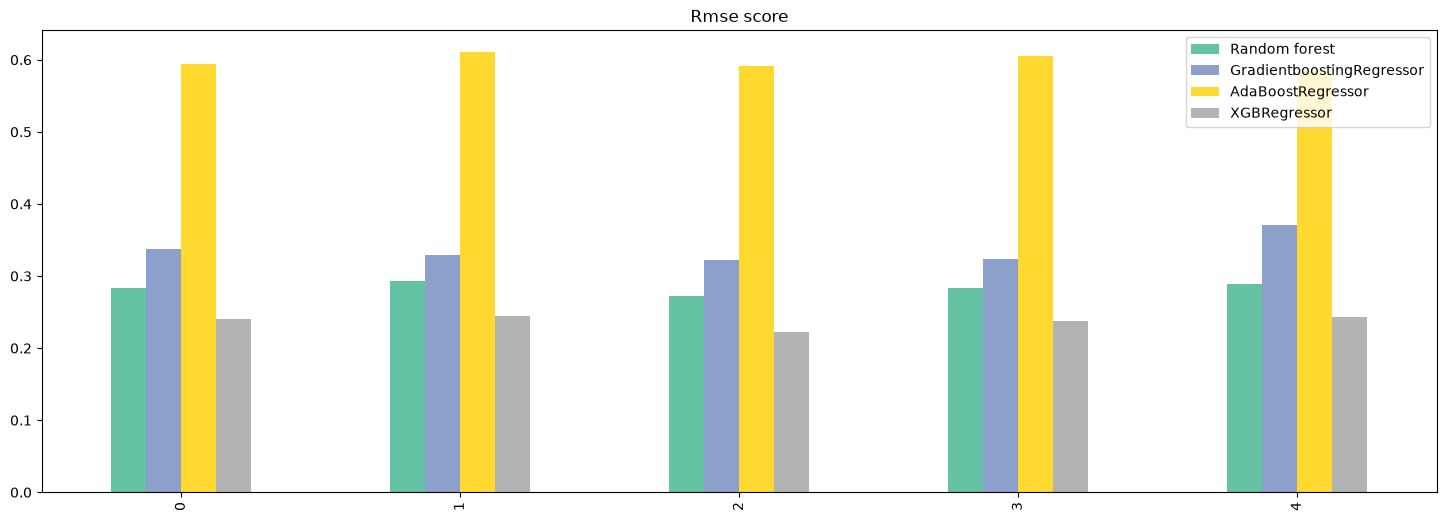

In [71]:
y1 = ["Random forest", "GradientboostingRegressor", "AdaBoostRegressor", "XGBRegressor"]
rf_xgb.plot.bar(y=y1, figsize=(18,6), colormap='Set2')
plt.title('Rmse score')

In [72]:
param_grids_xgb = {'max_depth' : [3, 4, 5],'min_child_weight' : [1, 3, 5],'reg_lambda' : [25, 15, 20],'n_estimators':[50, 25],'learning_rate':[0.05, 0.1, 0.2]}
xgb = XGBRegressor(random_state=40, objective='reg:squarederror')
grid = GridSearchCV(estimator=xgb, param_grid=param_grids_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(xtrain, ytrain)
print('best params:', grid.best_params_)
print('best RMSE:', np.sqrt(-grid.best_score_))

best params: {'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 50, 'reg_lambda': 15}
best RMSE: 0.2656582455310535


In [73]:
best_model = grid.best_estimator_
train_pred = best_model.predict(xtrain)
train_rmse = sqrt(mean_squared_error(ytrain, train_pred))

test_pred = best_model.predict(xtest)
test_rmse = sqrt(mean_squared_error(ytest, test_pred))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
#better then before cab booking train rmse is 0.1073 and test rmse is 0.3198 almost the difference is 0.2125

Train RMSE: 0.23511094647957456
Test RMSE: 0.27702666782013785


In [74]:
from sklearn.metrics import r2_score
test_r2 = r2_score(ytest, test_pred)
train_r2 = r2_score(ytrain, train_pred)
print('test r2 score (Accuracy):', test_r2)
print('train r2 score:', train_r2)
#better then before cab booking score before the train score is 0.98 but test score is 0.88 almost 10% in comparison

test r2 score (Accuracy): 0.9224521972978237
train r2 score: 0.9447228428454786


Text(0.5, 1.0, 'Feature Importances')

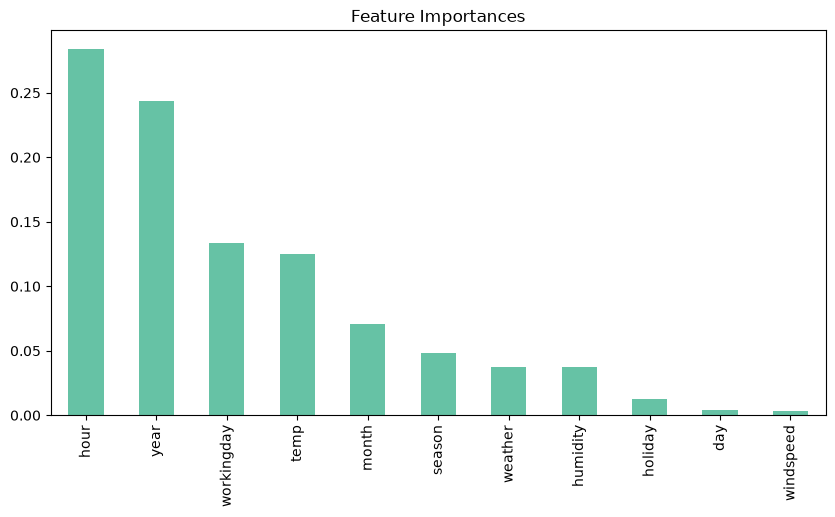

In [75]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=xtrain.columns).sort_values(ascending=False)
feat_imp.plot.bar(figsize=(10,5), colormap='Set2')
plt.title('Feature Importances')
#ye show kr rha hai ki data mein konse columns sbse zyda importance rakhte hain

In [76]:
import joblib
joblib.dump(best_model, 'xgb_cab_booking_model.joblib')
joblib.dump(st, 'scaler.joblib')

raw = pd.read_csv('train.csv')
season_enc = LabelEncoder()
season_enc.fit(raw['season'])
weather_enc = LabelEncoder()
weather_enc.fit(raw['weather'])
joblib.dump(season_enc, 'season_encoder.joblib')
joblib.dump(weather_enc, 'weather_encoder.joblib')

['weather_encoder.joblib']

## Conclusion

XGBoost Regressor performed best among all 8 models tested (Linear Regression, Decision Tree, 
KNN, Ridge, Lasso, Random Forest, Gradient Boosting, AdaBoost), giving the lowest RMSE.

Initial tuning showed strong CV score but severe overfitting (Train RMSE: 0.078, Test RMSE: 0.749). 
This was fixed by reducing model complexity (lower max_depth, higher reg_lambda) and correcting 
a scaling bug where the test set was being fit separately instead of just transformed using the 
train scaler.

*Final Model — Train RMSE: 0.235, Test RMSE: 0.277 (R² = 0.92)* — a small, healthy gap confirming 
good generalization.

Compared to the reference implementation (Train RMSE: 0.107, Test RMSE: 0.320 — a much larger gap), 
this model is more reliable despite a higher train error, since the reference version was 
overfitting without being detected.

*Key takeaway:* A good cross-validation score alone isn't enough — comparing train vs test 
performance was essential to catching and fixing overfitting.

### Deployment

The final model, along with the scaler and label encoders used during 
preprocessing, was saved using joblib and served through a FastAPI 
application. This exposes a /predict endpoint that accepts raw booking 
details, applies the same preprocessing pipeline used during training 
(encoding and scaling), and returns the predicted booking count — making 
the model usable outside the notebook.